# HW13 — токенизация текста, инференс BERT и базовый fine-tuning

Обязательная часть выполнена на датасете `emotion` с одним основным экспериментом fine-tuning.

## План
1. Импорты, seed, устройство.
2. Загрузка и sanity-check датасета.
3. Разбор токенизации на нескольких примерах.
4. Инференс готовой pretrained-модели.
5. Fine-tuning одной BERT-подобной модели.
6. Финальная оценка (`accuracy`, `f1_macro`), матрица ошибок и примеры предсказаний.

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)

import datasets
import transformers
import sklearn

print('torch:', torch.__version__)
print('datasets:', datasets.__version__)
print('transformers:', transformers.__version__)
print('sklearn:', sklearn.__version__)

C:\Users\kiril\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch: 2.11.0+cpu
datasets: 4.8.4
transformers: 5.5.0
sklearn: 1.8.0


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

DATASET_NAME = "emotion"
INFERENCE_MODEL_NAME = "distilbert-base-uncased-finetuned-sst-2-english"
FINETUNE_MODEL_NAME = "distilbert-base-uncased"

MAX_LENGTH = 96
TRAIN_MAX_SAMPLES = 1200
VAL_MAX_SAMPLES = 400
TEST_MAX_SAMPLES = 400
NUM_EPOCHS = 1
TRAIN_BS = 16
EVAL_BS = 32
LR = 3e-5

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print("Artifacts dir:", ARTIFACTS_DIR.resolve())

Device: cpu
Artifacts dir: C:\ucheba\ai\Damir\homeworks\HW13\artifacts


## 1. Данные и первичный анализ

In [3]:
raw_datasets = load_dataset(DATASET_NAME)
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [4]:
label_names = raw_datasets["train"].features["label"].names
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in id2label.items()}

split_sizes = {split: len(raw_datasets[split]) for split in raw_datasets.keys()}
print("Split sizes:", split_sizes)
print("Classes:", label_names)

preview_df = pd.DataFrame(raw_datasets["train"][:5])
preview_df["label_name"] = preview_df["label"].map(id2label)
display(preview_df[["text", "label", "label_name"]])

print("Постановка: multi-class классификация эмоций по тексту (6 классов).")

Split sizes: {'train': 16000, 'validation': 2000, 'test': 2000}
Classes: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


Постановка: multi-class классификация эмоций по тексту (6 классов).


## 2. Токенизация (базовый разбор)

In [5]:
tokenizer_demo = AutoTokenizer.from_pretrained(FINETUNE_MODEL_NAME)
print("Tokenizer:", tokenizer_demo.__class__.__name__)
print("Special tokens:", tokenizer_demo.special_tokens_map)

sample_indices = [0, 1, 2, 3, 4]
sample_texts = [raw_datasets["train"][i]["text"] for i in sample_indices]
sample_true_labels = [id2label[raw_datasets["train"][i]["label"]] for i in sample_indices]

rows = []
for text, true_label in zip(sample_texts, sample_true_labels):
    encoded = tokenizer_demo(text, add_special_tokens=True)
    tokens = tokenizer_demo.convert_ids_to_tokens(encoded["input_ids"])
    rows.append(
        {
            "text": text,
            "true_label": true_label,
            "tokens": tokens[:20],
            "input_ids": encoded["input_ids"][:20],
            "attention_mask": encoded["attention_mask"][:20],
            "n_tokens": len(encoded["input_ids"]),
        }
    )

token_demo_df = pd.DataFrame(rows)
display(token_demo_df[["text", "true_label", "tokens", "input_ids", "attention_mask", "n_tokens"]])

Tokenizer: BertTokenizer
Special tokens: {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}


,text,true_label,tokens,input_ids,attention_mask,n_tokens
0,i didnt feel humiliated,sadness,"[[CLS], i, didn, ##t, feel, humiliated, [SEP]]","[101, 1045, 2134, 2102, 2514, 26608, 102]","[1, 1, 1, 1, 1, 1, 1]",7
1,i can go from feeling so hopeless to so damned...,sadness,"[[CLS], i, can, go, from, feeling, so, hopeles...","[101, 1045, 2064, 2175, 2013, 3110, 2061, 2062...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",23
2,im grabbing a minute to post i feel greedy wrong,anger,"[[CLS], im, grabbing, a, minute, to, post, i, ...","[101, 10047, 9775, 1037, 3371, 2000, 2695, 104...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]",12
3,i am ever feeling nostalgic about the fireplac...,love,"[[CLS], i, am, ever, feeling, nos, ##tal, ##gi...","[101, 1045, 2572, 2412, 3110, 16839, 9080, 128...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",22
4,i am feeling grouchy,anger,"[[CLS], i, am, feeling, gr, ##ou, ##chy, [SEP]]","[101, 1045, 2572, 3110, 24665, 7140, 11714, 102]","[1, 1, 1, 1, 1, 1, 1, 1]",8


In [6]:
short_text = "I feel great"
long_text = " ".join(["This movie is surprisingly emotional and intense"] * 40)

enc = tokenizer_demo(
    [short_text, long_text],
    padding="max_length",
    truncation=True,
    max_length=32,
    return_tensors="pt",
)

print("input_ids shape:", tuple(enc["input_ids"].shape))
print("attention_mask shape:", tuple(enc["attention_mask"].shape))
print("Short text attention sum:", int(enc["attention_mask"][0].sum()))
print("Long text attention sum (after truncation):", int(enc["attention_mask"][1].sum()))
print("Decoded long text (truncated):")
print(tokenizer_demo.decode(enc["input_ids"][1]))

input_ids shape: (2, 32)
attention_mask shape: (2, 32)
Short text attention sum: 5
Long text attention sum (after truncation): 32
Decoded long text (truncated):
[CLS] this movie is surprisingly emotional and intense this movie is surprisingly emotional and intense this movie is surprisingly emotional and intense this movie is surprisingly emotional and intense this movie [SEP]


## 3. Инференс готовой pretrained-модели

In [7]:
pipe_device = 0 if DEVICE == "cuda" else -1
sentiment_pipe = pipeline(
    "text-classification",
    model=INFERENCE_MODEL_NAME,
    tokenizer=INFERENCE_MODEL_NAME,
    device=pipe_device,
)

inference_results = sentiment_pipe(sample_texts)
inf_df = pd.DataFrame(
    {
        "text": sample_texts,
        "true_emotion_label": sample_true_labels,
        "pretrained_label": [x["label"] for x in inference_results],
        "pretrained_score": [x["score"] for x in inference_results],
    }
)
display(inf_df)

print(
    "Комментарий: модель обучена на sentiment (SST-2), а не на emotion-классах, "
    "поэтому её метки напрямую не совпадают с нашей целевой постановкой."
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1924.77it/s]

,text,true_emotion_label,pretrained_label,pretrained_score
0,i didnt feel humiliated,sadness,POSITIVE,0.891336
1,i can go from feeling so hopeless to so damned...,sadness,POSITIVE,0.966551
2,im grabbing a minute to post i feel greedy wrong,anger,NEGATIVE,0.999305
3,i am ever feeling nostalgic about the fireplac...,love,POSITIVE,0.965797
4,i am feeling grouchy,anger,NEGATIVE,0.999391


Комментарий: модель обучена на sentiment (SST-2), а не на emotion-классах, поэтому её метки напрямую не совпадают с нашей целевой постановкой.


## 4. Fine-tuning для классификации текста (один обязательный эксперимент)

In [8]:
def take_subset(ds, n, seed=SEED):
    n = min(n, len(ds))
    return ds.shuffle(seed=seed).select(range(n))

subset_raw = DatasetDict(
    {
        "train": take_subset(raw_datasets["train"], TRAIN_MAX_SAMPLES),
        "validation": take_subset(raw_datasets["validation"], VAL_MAX_SAMPLES),
        "test": take_subset(raw_datasets["test"], TEST_MAX_SAMPLES),
    }
)

print({k: len(v) for k, v in subset_raw.items()})

{'train': 1200, 'validation': 400, 'test': 400}


In [9]:
tokenizer = AutoTokenizer.from_pretrained(FINETUNE_MODEL_NAME)


def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)


tokenized = subset_raw.map(tokenize_batch, batched=True)
tokenized = tokenized.remove_columns(["text"]).rename_column("label", "labels")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(
    FINETUNE_MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)

model.to(DEVICE)
print("Fine-tune model:", FINETUNE_MODEL_NAME)
print("num_labels:", model.config.num_labels)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3198.66it/s]


DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tune model: distilbert-base-uncased
num_labels: 6


In [10]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

import shutil
shutil.rmtree(ARTIFACTS_DIR / "trainer_output", ignore_errors=True)

common_args = dict(
    output_dir=str(ARTIFACTS_DIR / "trainer_output"),
    learning_rate=LR,
    per_device_train_batch_size=TRAIN_BS,
    per_device_eval_batch_size=EVAL_BS,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=0.01,
    logging_steps=25,
    report_to="none",
    seed=SEED,
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="no",
        **common_args,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="no",
        **common_args,
    )

try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

trainer

In [11]:
train_result = trainer.train()
print(train_result)

C:\Users\kiril\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.342348,1.392298,0.517500,0.216020


TrainOutput(global_step=75, training_loss=1.5308996073404948, metrics={'train_runtime': 113.7302, 'train_samples_per_second': 10.551, 'train_steps_per_second': 0.659, 'total_flos': 14870526202368.0, 'train_loss': 1.5308996073404948, 'epoch': 1.0})


In [12]:
try:
    from transformers.utils.notebook import NotebookProgressCallback
    trainer.remove_callback(NotebookProgressCallback)
except Exception:
    pass

val_metrics = trainer.evaluate(tokenized["validation"])
test_metrics = trainer.evaluate(tokenized["test"])

print("Validation metrics:")
for k, v in val_metrics.items():
    if isinstance(v, (int, float)):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

print("Test metrics:")
for k, v in test_metrics.items():
    if isinstance(v, (int, float)):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")

pred_out = trainer.predict(tokenized["test"])
test_logits = pred_out.predictions[0] if isinstance(pred_out.predictions, tuple) else pred_out.predictions
test_true = pred_out.label_ids
test_pred = np.argmax(test_logits, axis=-1)
test_probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()

test_acc = accuracy_score(test_true, test_pred)
test_f1_macro = f1_score(test_true, test_pred, average="macro")
print("Final test_accuracy:", round(test_acc, 4))
print("Final test_f1_macro:", round(test_f1_macro, 4))

C:\Users\kiril\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


C:\Users\kiril\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation metrics:
eval_loss: 1.3923
eval_accuracy: 0.5175
eval_f1_macro: 0.2160
eval_runtime: 7.9757
eval_samples_per_second: 50.1520
eval_steps_per_second: 1.6300
epoch: 1.0000
Test metrics:
eval_loss: 1.2603
eval_accuracy: 0.6225
eval_f1_macro: 0.2441
eval_runtime: 7.7393
eval_samples_per_second: 51.6840
eval_steps_per_second: 1.6800
epoch: 1.0000


C:\Users\kiril\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Final test_accuracy: 0.6225
Final test_f1_macro: 0.2441


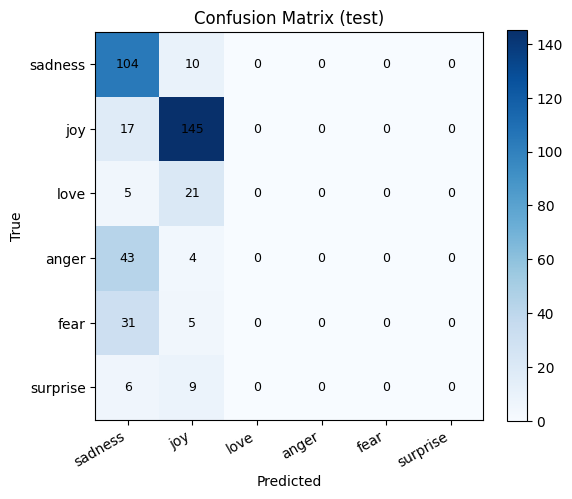

Saved: C:\ucheba\ai\Damir\homeworks\HW13\artifacts\confusion_matrix.png


In [13]:
cm = confusion_matrix(test_true, test_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix (test)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_yticklabels(label_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=9)

plt.colorbar(im, ax=ax)
plt.tight_layout()

cm_path = ARTIFACTS_DIR / "confusion_matrix.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", cm_path.resolve())

In [14]:
test_texts = subset_raw["test"]["text"]

sample_pred_df = pd.DataFrame(
    {
        "text": test_texts,
        "true_label": [id2label[int(x)] for x in test_true],
        "pred_label": [id2label[int(x)] for x in test_pred],
        "confidence": test_probs.max(axis=1),
    }
)

sample_pred_path = ARTIFACTS_DIR / "sample_predictions.csv"
sample_pred_df.to_csv(sample_pred_path, index=False, encoding="utf-8")
print("Saved:", sample_pred_path.resolve())

display(sample_pred_df.head(10))

Saved: C:\ucheba\ai\Damir\homeworks\HW13\artifacts\sample_predictions.csv


,text,true_label,pred_label,confidence
0,i was feeling really troubled and down over wh...,sadness,sadness,0.408688
1,i feel so thrilled to have three such distingu...,joy,joy,0.521980
2,i feel is that the most likeable characters ar...,joy,joy,0.329773
3,i tune out the rest of the world and focus on ...,joy,joy,0.490341
4,i sit here writing this i feel unhappy inside,sadness,sadness,0.400951
5,im feeling and if ive liked being pregnant,love,joy,0.473759
6,im very hurt and i feel unimportant,sadness,sadness,0.402806
7,i used to be able to hang around talk with the...,anger,sadness,0.388638
8,i don t have the feeling of divine vibrations,joy,joy,0.368817
9,i vented my feelings towards the pathetic excu...,sadness,sadness,0.383719


In [15]:
errors_df = sample_pred_df[sample_pred_df["true_label"] != sample_pred_df["pred_label"]].copy()
errors_df = errors_df.sort_values("confidence", ascending=False)

print("Ошибок на test:", len(errors_df), "из", len(sample_pred_df))
display(errors_df.head(8))

print("Короткий комментарий:")
print(
    "Чаще всего ошибки возникают на эмоционально близких классах "
    "(например, joy/love или anger/fear), где контекст короткий и неоднозначный."
)

Ошибок на test: 151 из 400


,text,true_label,pred_label,confidence
249,im feeling generous today heres one more you m...,love,joy,0.548635
385,ive got a off sale the ad says starting tomorr...,love,joy,0.543140
13,i cant write a review for a book i adore unles...,love,joy,0.520038
134,i go through my day feeling your movements and...,surprise,joy,0.516619
62,i feel about this part of my life and how trea...,love,joy,0.515599
239,i know some people are more fond of the treat ...,love,joy,0.512344
132,i understand that they are reacting to what we...,love,joy,0.509667
383,i feel blessed beyond blessed to share my life...,love,joy,0.507822


Короткий комментарий:
Чаще всего ошибки возникают на эмоционально близких классах (например, joy/love или anger/fear), где контекст короткий и неоднозначный.


In [16]:
summary = {
    "dataset": DATASET_NAME,
    "inference_model": INFERENCE_MODEL_NAME,
    "finetune_model": FINETUNE_MODEL_NAME,
    "train_size": len(subset_raw["train"]),
    "validation_size": len(subset_raw["validation"]),
    "test_size": len(subset_raw["test"]),
    "max_length": MAX_LENGTH,
    "train_batch_size": TRAIN_BS,
    "eval_batch_size": EVAL_BS,
    "num_epochs": NUM_EPOCHS,
    "learning_rate": LR,
    "test_accuracy": float(test_acc),
    "test_f1_macro": float(test_f1_macro),
}

summary_df = pd.DataFrame([summary])
display(summary_df)

summary_path = ARTIFACTS_DIR / "metrics_summary.csv"
summary_df.to_csv(summary_path, index=False)
print("Saved:", summary_path.resolve())

,dataset,inference_model,finetune_model,train_size,validation_size,test_size,max_length,train_batch_size,eval_batch_size,num_epochs,learning_rate,test_accuracy,test_f1_macro
0,emotion,distilbert-base-uncased-finetuned-sst-2-english,distilbert-base-uncased,1200,400,400,96,16,32,1,0.00003,0.6225,0.244101


Saved: C:\ucheba\ai\Damir\homeworks\HW13\artifacts\metrics_summary.csv


## Короткий вывод
- Токенизация показывает преобразование текста в `input_ids`/`attention_mask` с special tokens и контролем длины через `padding`/`truncation`.
- Готовая sentiment-модель даёт ориентировочные предсказания, но не совпадает по пространству классов с задачей `emotion`.
- Fine-tuning BERT-подобной модели на целевом датасете даёт валидную итоговую оценку на `test` (`accuracy` и `f1_macro`) и позволяет построить матрицу ошибок.